# Predicting F1 Pit Stops

In [ ]:
import joblib
import optuna
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler, KBinsDiscretizer

from IPython.display import clear_output
from pathlib import Path
import sys
import warnings

warnings.filterwarnings('ignore', message='X does not have valid feature names')

cwd = Path().cwd()
project_root = cwd if (cwd / "utils").exists() else cwd.parent
sys.path.append(str(project_root))
from utils.model_hub import Models_hub

RANDOM_SEED = 42
models_hub = Models_hub(random_state=RANDOM_SEED)
save_path = "src/Predicting F1 Pit Stops/saved_models"
pre_trained_models = {
    'XGBClassifier': True,
    'LGBMClassifier': False,
    'CatBoostClassifier': False,
}

### EDA

In [8]:
train = pd.read_csv('./data/train.csv')
test = pd.read_csv('./data/test.csv')

train.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


* **id** — уникальный идентификатор записи
* **Driver** — идентификатор гонщика (например, D109)
* **Compound** — тип шин (HARD, MEDIUM, SOFT)
* **Race** — название гонки (этап чемпионата)
* **Year** — год проведения гонки
* **PitStop** — был ли пит-стоп на текущем круге (1 — да, 0 — нет)
* **LapNumber** — номер текущего круга
* **Stint** — номер отрезка на текущем комплекте шин (между пит-стопами)
* **TyreLife** — возраст шин (количество кругов, пройденных на этом комплекте)
* **Position** — текущая позиция гонщика в гонке
* **LapTime (s)** — время круга в секундах
* **LapTime_Delta** — изменение времени круга относительно предыдущего круга или базового значения
* **Cumulative_Degradation** — накопленная деградация шин (ухудшение их эффективности)
* **RaceProgress** — прогресс гонки (доля пройденной дистанции, от 0 до 1)
* **Position_Change** — изменение позиции относительно предыдущего круга
* **PitNextLap** — целевая переменная: будет ли пит-стоп на следующем круге (1 — да, 0 — нет)


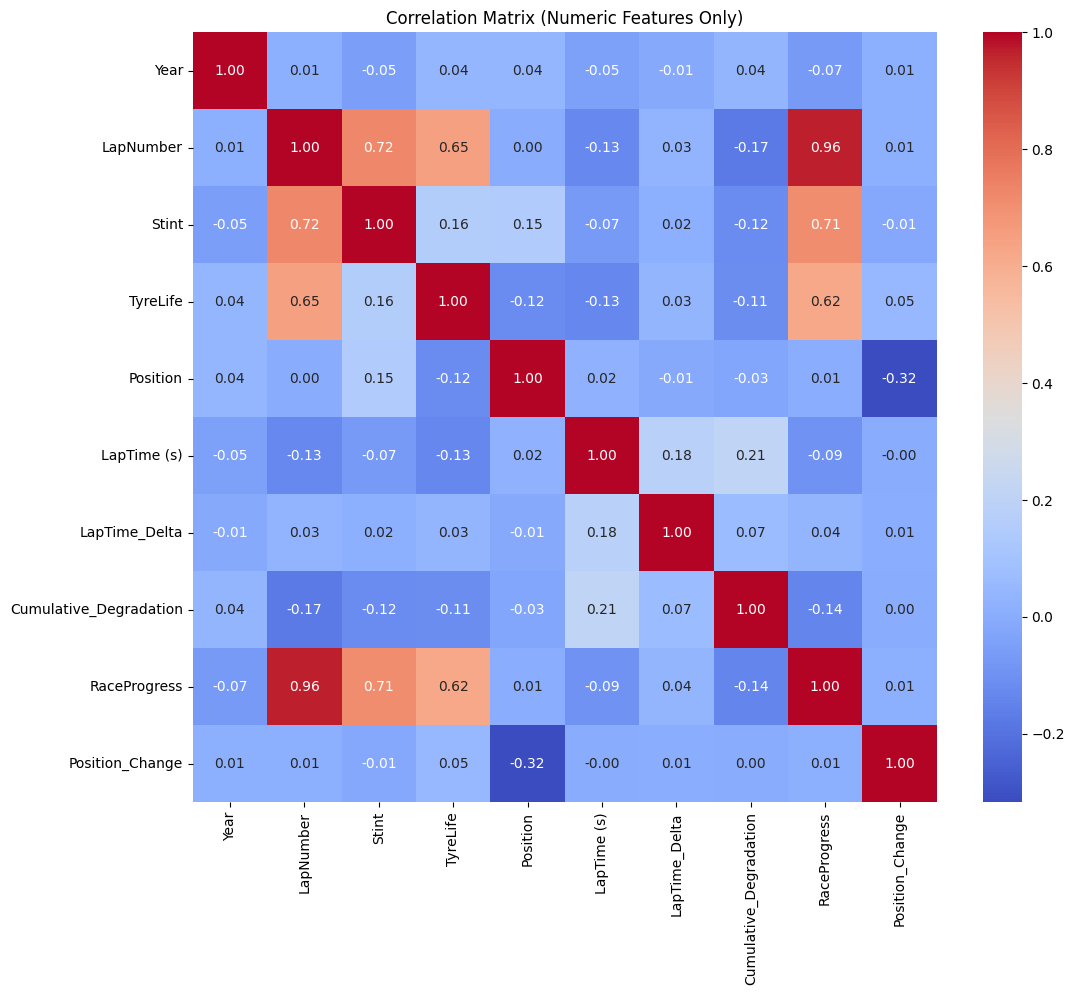

In [9]:
categorical_features = ['Driver', 'Compound', 'Race']
numerical_features = ['Year', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change']
x_merged = pd.concat([train[numerical_features], test[numerical_features]], axis=0)
plt.figure(figsize=(12, 10))
sns.heatmap(x_merged.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix (Numeric Features Only)')
plt.show()

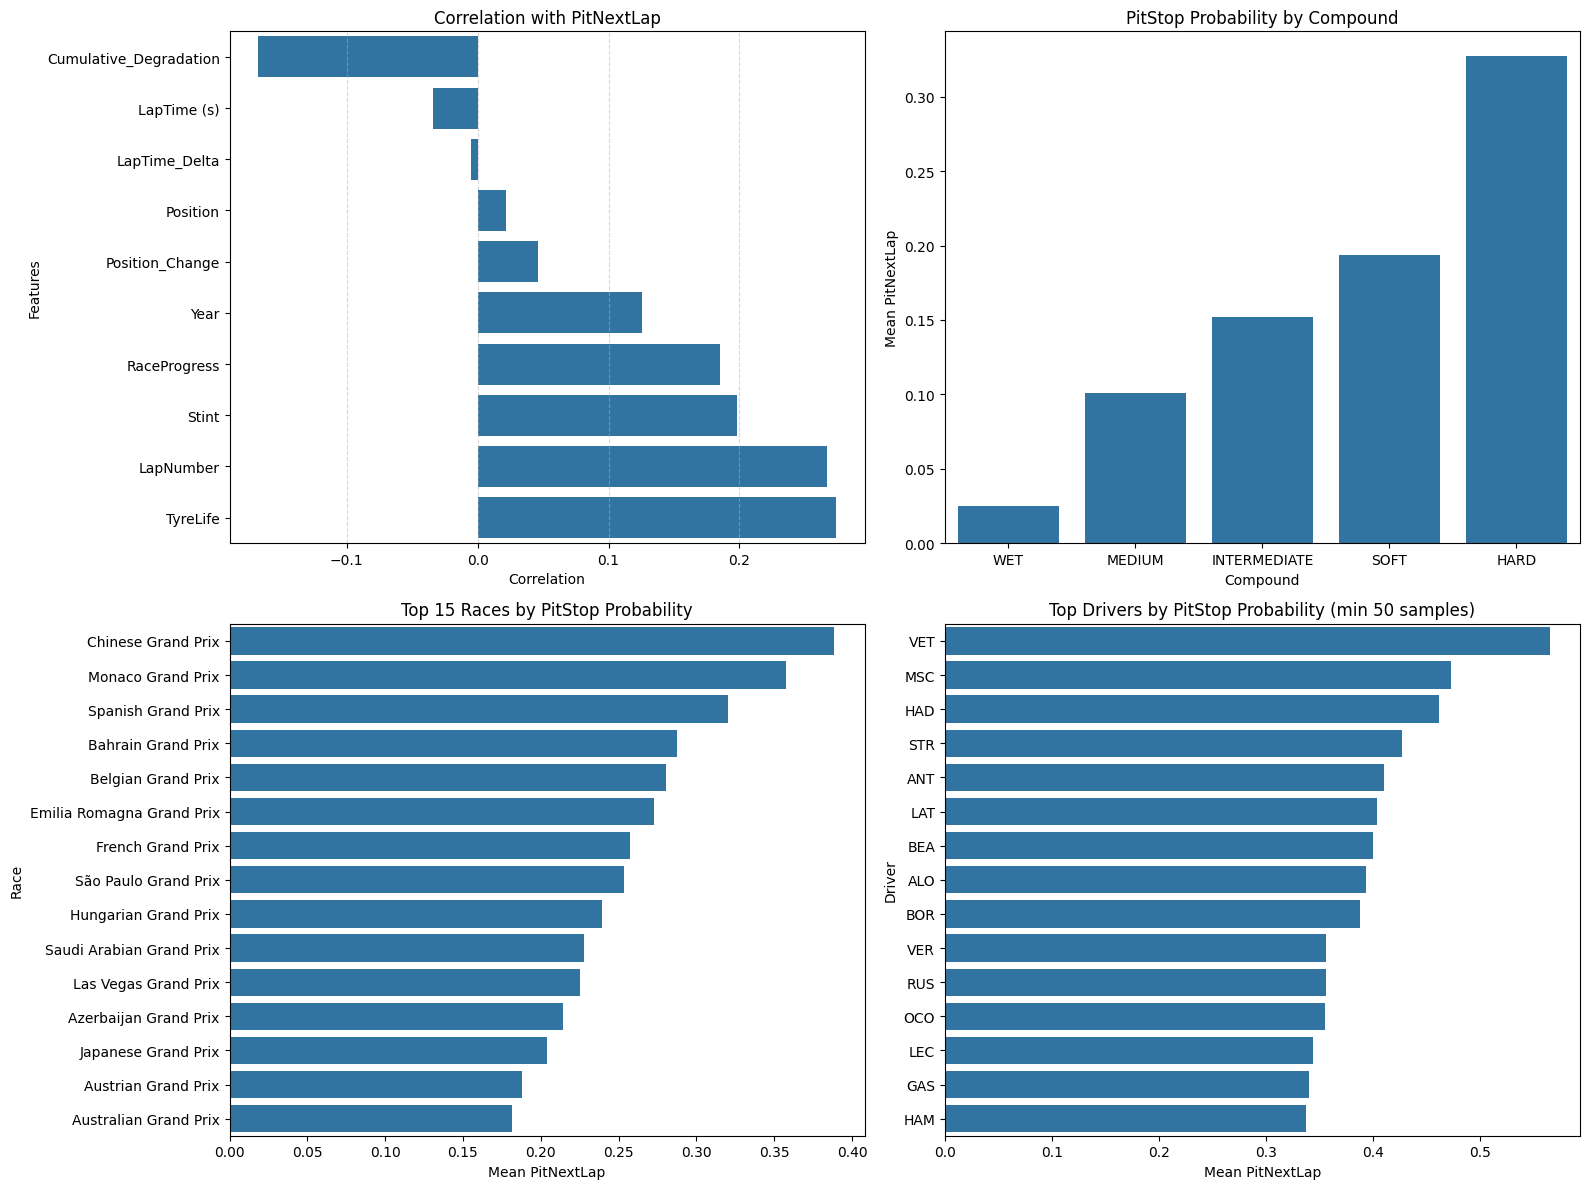

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Корреляция числовых признаков с таргетом
corr = train[numerical_features].corrwith(train['PitNextLap']).sort_values()
sns.barplot(x=corr.values, y=corr.index, ax=axes[0, 0])
axes[0, 0].set_title("Correlation with PitNextLap")
axes[0, 0].set_xlabel("Correlation")
axes[0, 0].set_ylabel("Features")
axes[0, 0].grid(axis='x', linestyle='--', alpha=0.5)

# 2. Compound
compound_mean = train.groupby('Compound')['PitNextLap'].mean().sort_values()
sns.barplot(x=compound_mean.index, y=compound_mean.values, ax=axes[0, 1])
axes[0, 1].set_title("PitStop Probability by Compound")
axes[0, 1].set_xlabel("Compound")
axes[0, 1].set_ylabel("Mean PitNextLap")

# 3. Race (топ-15)
race_mean = train.groupby('Race')['PitNextLap'].mean().sort_values(ascending=False).head(15)
sns.barplot(x=race_mean.values, y=race_mean.index, ax=axes[1, 0])
axes[1, 0].set_title("Top 15 Races by PitStop Probability")
axes[1, 0].set_xlabel("Mean PitNextLap")
axes[1, 0].set_ylabel("Race")

# 4. Driver (фильтр по частоте)
driver_mean = train.groupby('Driver')['PitNextLap'].mean()
driver_count = train['Driver'].value_counts()

valid_drivers = driver_count[driver_count > 50].index
driver_mean = driver_mean.loc[valid_drivers].sort_values(ascending=False).head(15)

sns.barplot(x=driver_mean.values, y=driver_mean.index, ax=axes[1, 1])
axes[1, 1].set_title("Top Drivers by PitStop Probability (min 50 samples)")
axes[1, 1].set_xlabel("Mean PitNextLap")
axes[1, 1].set_ylabel("Driver")

plt.tight_layout()
plt.show()

In [18]:
FS_A = {}
COMBO_COLS = [('Race', 'Compound'), ('Race', 'Year'), ('Driver', 'Compound')]
COMBO_NAMES_A = [f"{c1}_{c2}_" for c1, c2 in COMBO_COLS]

COMPOUND_MAX_LIFE_MAP = {'SOFT': 15, 'MEDIUM': 30, 'HARD': 50, 'INTERMEDIATE': 25, 'WET': 20}
HIST_PIT_PRIORS = {}

def _ndrv(s):
    return str(s).strip().split()[-1].lower()

def _nrace(s):
    s = str(s).strip().lower()
    s = re.sub(r'grand\s+prix|\bgp\b', '', s).strip()
    return s

def make_features_A(df, fit=False):
    df = df.copy().sort_values(['Driver', 'Race', 'Year', 'LapNumber']).reset_index(drop=True)
    g = df.groupby(['Driver', 'Race', 'Year'])
    g_stint = df.groupby(['Driver', 'Race', 'Year', 'Stint'])

    df['tyre_life_sq'] = df['TyreLife'] ** 2
    df['tyre_life_log'] = np.log1p(df['TyreLife'])
    df['tyre_life_sqrt'] = np.sqrt(df['TyreLife'])
    df['deg_per_lap'] = df['Cumulative_Degradation'] / (df['TyreLife'] + 1)
    df['compound_life_ratio'] = df['TyreLife'] / (df.groupby('Compound')['TyreLife'].transform('max') + 1e-9)
    df['compound_max_life'] = df['Compound'].map(COMPOUND_MAX_LIFE_MAP).fillna(30)
    df['compound_tyre_norm'] = (df['TyreLife'] / df['compound_max_life']).clip(0, 2)
    df['tyre_overdue_norm'] = (df['compound_tyre_norm'] > 0.85).astype(int)

    df['est_total_laps'] = (df['LapNumber'] / (df['RaceProgress'] + 1e-9)).round().clip(30, 80)
    df['laps_remaining'] = (df['est_total_laps'] - df['LapNumber']).clip(lower=0)
    df['tyre_pct_remaining'] = df['TyreLife'] / (df['laps_remaining'] + 1)
    df['is_pit_window'] = ((df['RaceProgress'] >= 0.28) & (df['RaceProgress'] <= 0.62)).astype(int)
    df['is_late_race'] = (df['RaceProgress'] > 0.75).astype(int)
    df['position_pressure'] = df['Position'] * (1 - df['RaceProgress'])
    df['urgency_score'] = df['Cumulative_Degradation'].abs() * (1 - df['RaceProgress'])
    df['race_phase'] = pd.cut(df['RaceProgress'], bins=[0, .25, .5, .75, 1.01], labels=[0, 1, 2, 3]).astype(float)
    df['norm_position'] = 1 - (df['Position'] - 1) / 19.0
    df['life_x_progress'] = df['TyreLife'] * df['RaceProgress']

    df['delta_lag1'] = g['LapTime_Delta'].shift(1)
    df['delta_lag2'] = g['LapTime_Delta'].shift(2)
    df['prev_pit'] = g['PitStop'].shift(1).fillna(0)
    df['delta_accel'] = df['LapTime_Delta'] - df['delta_lag1']
    df['roll3_lt'] = g['LapTime (s)'].transform(lambda x: x.rolling(3, min_periods=1).mean())
    df['roll5_lt'] = g['LapTime (s)'].transform(lambda x: x.rolling(5, min_periods=1).mean())
    df['roll7_lt'] = g['LapTime (s)'].transform(lambda x: x.rolling(7, min_periods=1).mean())
    df['roll10_lt'] = g['LapTime (s)'].transform(lambda x: x.rolling(10, min_periods=1).mean())
    df['roll15_lt'] = g['LapTime (s)'].transform(lambda x: x.rolling(15, min_periods=1).mean())
    df['roll3_d'] = g['LapTime_Delta'].transform(lambda x: x.rolling(3, min_periods=1).mean())
    df['roll7_d'] = g['LapTime_Delta'].transform(lambda x: x.rolling(7, min_periods=1).mean())
    df['roll3_std'] = g['LapTime (s)'].transform(lambda x: x.rolling(3, min_periods=1).std().fillna(0))
    df['lap_vs_r3'] = df['LapTime (s)'] - df['roll3_lt']
    df['lap_vs_r5'] = df['LapTime (s)'] - df['roll5_lt']
    df['lap_vs_r7'] = df['LapTime (s)'] - df['roll7_lt']
    df['lap_vs_r10'] = df['LapTime (s)'] - df['roll10_lt']
    df['deg_velocity'] = g['Cumulative_Degradation'].transform(lambda x: x.diff(3).fillna(0) / 3)
    df['is_slow_lap'] = (df['LapTime (s)'] > df['roll5_lt'] * 1.15).astype(int)
    df['lap_in_stint'] = g_stint.cumcount()
    df['stint_start_lap'] = g_stint['LapNumber'].transform('min')

    if fit:
        FS_A['pit_laps'] = df[df['PitNextLap'] == 1].groupby(['Race', 'Year'])['LapNumber'].mean().rename('race_avg_pit_lap')
        FS_A['total_laps'] = df.groupby(['Race', 'Year'])['LapNumber'].max().rename('race_total_laps')
        FS_A['comp_life'] = df[df['PitNextLap'] == 1].groupby('Compound')['TyreLife'].mean().rename('compound_avg_life')
        FS_A['race_stints'] = df.groupby(['Race', 'Year'])['Stint'].max().rename('race_max_stint')
    df = df.merge(FS_A['pit_laps'].reset_index(), on=['Race', 'Year'], how='left')
    df = df.merge(FS_A['total_laps'].reset_index(), on=['Race', 'Year'], how='left')
    df = df.merge(FS_A['comp_life'].reset_index(), on='Compound', how='left')
    df = df.merge(FS_A['race_stints'].reset_index(), on=['Race', 'Year'], how='left')
    df['pit_window_flag'] = (np.abs(df['LapNumber'] - df['race_avg_pit_lap'].fillna(35)) <= 3).astype(int)
    df['tyre_vs_comp_avg'] = df['TyreLife'] - df['compound_avg_life'].fillna(25)
    df['overdue_pit'] = (df['TyreLife'] > df['compound_avg_life'].fillna(25)).astype(int)
    df['laps_remaining_race'] = df['race_total_laps'].fillna(60) - df['LapNumber']
    df['tyre_age_pct_race'] = df['TyreLife'] / (df['race_total_laps'].fillna(60) + 1)
    df['stint_progress'] = df['Stint'] / (df['race_max_stint'].fillna(3) + 1)
    df['tyre_life_pct'] = df['TyreLife'] / df['compound_avg_life'].fillna(25).clip(lower=1)
    df['stint_end_est'] = df['stint_start_lap'] + df['compound_avg_life'].fillna(25)
    df['laps_until_stop'] = (df['stint_end_est'] - df['LapNumber']).clip(lower=-20)
    df['pit_imminent'] = (df['laps_until_stop'] <= 2).astype(int)
    df['pit_in_5'] = (df['laps_until_stop'] <= 5).astype(int)

    df['cliff_flag'] = ((df['LapTime_Delta'] > df['roll3_d'].fillna(0) + 2 * df['roll3_std'].fillna(0)) & (df['TyreLife'] > 15)).astype(int)
    df['laps_to_stop'] = df['compound_avg_life'].fillna(25) - df['TyreLife']
    df['past_optimal'] = (df['laps_to_stop'] < -3).astype(int)
    df['must_pit_or_stay'] = (df['laps_remaining_race'] < df['TyreLife'] * 0.4).astype(int)
    df['undercut_threat'] = ((df['Position'] <= 10) & (df['is_pit_window'] == 1)).astype(int)
    df['relative_stint'] = df['Stint'] / df['race_max_stint'].fillna(3).clip(lower=1)
    df['deg_x_win'] = df['Cumulative_Degradation'] * df['is_pit_window']
    df['over_x_win'] = df['overdue_pit'] * df['is_pit_window']
    df['tyre_x_pres'] = df['TyreLife'] * df['position_pressure']
    df['r3_x_life'] = df['roll3_d'].fillna(0) * df['TyreLife']
    df['comp_stint'] = df['Compound'].map({'SOFT': 2, 'MEDIUM': 1, 'HARD': 0}).fillna(1) * df['Stint']
    df['lap_div_rp'] = (df['LapNumber'] / (df['RaceProgress'] + 1e-6)).astype('float32')
    df['tl_div_ln'] = (df['TyreLife'] / df['LapNumber'].clip(lower=1)).astype('float32')
    df['lap_accel_smooth'] = g['LapTime_Delta'].transform(lambda x: x.rolling(5, min_periods=2).mean().diff().fillna(0))
    df['tyre_cliff_imminent'] = ((df['lap_accel_smooth'] > 0.3) & (df['TyreLife'] > 12)).astype(int)
    df['laps_to_window_start'] = (df['race_avg_pit_lap'].fillna(35) * 0.85 - df['LapNumber']).clip(-20, 30)
    df['laps_to_window_end'] = (df['race_avg_pit_lap'].fillna(35) * 1.15 - df['LapNumber']).clip(-20, 30)
    df['in_optimal_window'] = ((df['laps_to_window_start'] <= 0) & (df['laps_to_window_end'] >= 0)).astype(int)
    df['stint_lt_baseline'] = g_stint['LapTime (s)'].transform('first')
    df['stint_degradation_ratio'] = ((df['LapTime (s)'] - df['stint_lt_baseline']) / (df['stint_lt_baseline'] + 1e-9)).clip(-0.1, 0.3)
    if fit:
        FS_A['compound_race_lt'] = df.groupby(['Race', 'Year', 'Compound'])['LapTime (s)'].median().rename('compound_race_median_lt')
    df = df.merge(FS_A['compound_race_lt'].reset_index(), on=['Race', 'Year', 'Compound'], how='left')
    df['lap_vs_compound_baseline'] = (df['LapTime (s)'] - df['compound_race_median_lt'].fillna(df['LapTime (s)'])).clip(-5, 15)
    df['roll7_std'] = g['LapTime (s)'].transform(lambda x: x.rolling(7, min_periods=2).std().fillna(0))
    df['roll3_var_ratio'] = (df['roll3_std'] / (df['roll7_std'] + 1e-9)).clip(0, 5)
    df['pos_lag3'] = g['Position'].shift(3)
    df['pos_trend_3'] = (df['Position'] - df['pos_lag3'].fillna(df['Position'])).clip(-10, 10)
    df['losing_positions'] = (df['pos_trend_3'] > 1).astype(int)
    if fit:
        FS_A['race_compound_max'] = df.groupby(['Race', 'Year', 'Compound'])['TyreLife'].max().rename('race_compound_max_life')
    df = df.merge(FS_A['race_compound_max'].reset_index(), on=['Race', 'Year', 'Compound'], how='left')
    df['tyre_freshness_pct'] = (1 - df['TyreLife'] / (df['race_compound_max_life'].fillna(40) + 1)).clip(0, 1)
    df['must_pit_signal'] = (df['tyre_cliff_imminent'] * df['overdue_pit'] * df['in_optimal_window']).astype(int)
    df['urgency_composite'] = df['urgency_score'] * df['stint_degradation_ratio'].clip(0, 1) * (1 + df['tyre_cliff_imminent'])
    if fit:
        FS_A['driver_compound_avg_life'] = df[df['PitNextLap'] == 1].groupby(['Driver', 'Compound'])['TyreLife'].mean().rename('dc_avg_stint_life')
    _dc_life = FS_A.get('driver_compound_avg_life')
    if _dc_life is not None:
        df = df.merge(_dc_life.reset_index(), on=['Driver', 'Compound'], how='left')
    else:
        df['dc_avg_stint_life'] = 25.0
    df['driver_vs_avg_life'] = (df['TyreLife'] - df['dc_avg_stint_life'].fillna(25)).clip(-20, 20)
    df['driver_overdue_personal'] = (df['TyreLife'] > df['dc_avg_stint_life'].fillna(25)).astype(int)

    df['compound_ord'] = df['Compound'].map({'SOFT': 2, 'MEDIUM': 1, 'HARD': 0, 'INTERMEDIATE': 3, 'WET': 4}).fillna(1)
    df['year_le'] = df['Year'] - df['Year'].min()
    base_nums = ['PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change']
    for col in base_nums:
        cname = f"{col}_cat_"
        if fit:
            _, uniques = np.floor(df[col]).factorize()
            FS_A[f'nc_{col}'] = {v: i for i, v in enumerate(uniques)}
        df[cname] = np.floor(df[col]).map(FS_A[f'nc_{col}']).fillna(-1).astype('int32').astype(str)
    if fit:
        kb = KBinsDiscretizer(n_bins=200, encode='ordinal', strategy='quantile', subsample=None)
        df['rp_bin_'] = kb.fit_transform(df[['RaceProgress']]).ravel().astype('int32').astype(str)
        FS_A['kb'] = kb
    else:
        df['rp_bin_'] = FS_A['kb'].transform(df[['RaceProgress']]).ravel().astype('int32').astype(str)
    for c1, c2 in COMBO_COLS:
        cn = f"{c1}_{c2}_"
        combo = df[c1].astype(str) + '_' + df[c2].astype(str)
        if fit:
            _, uniques = combo.factorize()
            FS_A[cn] = {v: i for i, v in enumerate(uniques)}
        df[cn] = combo.map(FS_A[cn]).fillna(-1).astype('int32').astype(str)

    if fit and 'PitNextLap' in df.columns:
        teskf = StratifiedKFold(5, shuffle=True, random_state=RANDOM_SEED)
        gm = df['PitNextLap'].mean()
        for col in ['Driver', 'Race']:
            df[f'{col}_te'] = 0.0
            for ti, vi in teskf.split(df, df['PitNextLap']):
                m = df.iloc[ti].groupby(col)['PitNextLap'].mean()
                df.iloc[vi, df.columns.get_loc(f'{col}_te')] = df.iloc[vi][col].map(m).fillna(gm).values
            FS_A[f'{col}_te_map'] = df.groupby(col)['PitNextLap'].mean().to_dict()
        for (c1, c2), te_name in [(('Driver', 'Compound'), 'Driver_Compound_te'), (('Race', 'Compound'), 'Race_Compound_te')]:
            combined = (df[c1].astype(str) + '_' + df[c2].astype(str)).values
            df[te_name] = gm
            for ti, vi in teskf.split(df, df['PitNextLap']):
                m = pd.Series(df['PitNextLap'].values[ti], index=combined[ti]).groupby(level=0).mean()
                df.iloc[vi, df.columns.get_loc(te_name)] = pd.Series(combined[vi]).map(m).fillna(gm).values
            FS_A[f'{te_name}_map'] = pd.Series(df['PitNextLap'].values, index=combined).groupby(level=0).mean().to_dict()
    else:
        for col in ['Driver', 'Race']:
            gm = float(np.mean(list(FS_A.get(f'{col}_te_map', {}).values()) or [0.2]))
            df[f'{col}_te'] = df[col].map(FS_A.get(f'{col}_te_map', {})).fillna(gm)
        for (c1, c2), te_name in [(('Driver', 'Compound'), 'Driver_Compound_te'), (('Race', 'Compound'), 'Race_Compound_te')]:
            combined = (df[c1].astype(str) + '_' + df[c2].astype(str)).values
            gm = float(np.mean(list(FS_A.get(f'{te_name}_map', {}).values()) or [0.2]))
            df[te_name] = pd.Series(combined).map(FS_A.get(f'{te_name}_map', {})).fillna(gm).values

    df['_dk'] = df['Driver'].map(_ndrv)
    df['_rk'] = df['Race'].map(_nrace)
    df['_yr'] = df['Year'].astype(int)
    df.drop(columns=['_dk', '_rk', '_yr'], inplace=True, errors='ignore')
    return df.fillna(0)

print('Feature engineering function make_features_A is ready.')

Feature engineering function make_features_A is ready.


In [12]:
X_train_raw, X_val_raw = train_test_split(
    train,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=train['PitNextLap'],
)

train_A = make_features_A(X_train_raw.copy(), fit=True)
val_A = make_features_A(X_val_raw.copy(), fit=False)
test_A = make_features_A(test.copy(), fit=False)

y_train = train_A['PitNextLap'].astype(int)
y_val = val_A['PitNextLap'].astype(int)

drop_cols_train = ['id', 'PitNextLap']
drop_cols_test = ['id']

X_train_df = train_A.drop(columns=drop_cols_train, errors='ignore').copy()
X_val_df = val_A.drop(columns=drop_cols_train, errors='ignore').copy()
X_test_df = test_A.drop(columns=drop_cols_test, errors='ignore').copy()

# Align columns across splits before preprocessing
feature_cols = X_train_df.columns.tolist()
X_val_df = X_val_df.reindex(columns=feature_cols, fill_value=0)
X_test_df = X_test_df.reindex(columns=feature_cols, fill_value=0)

# Treat all string/categorical features as categorical for OHE
cat_cols_a = X_train_df.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols_a = [c for c in feature_cols if c not in cat_cols_a]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_a),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_a),
    ]
)

X_train = preprocessor.fit_transform(X_train_df)
X_val = preprocessor.transform(X_val_df)
X_test = preprocessor.transform(X_test_df)

X_train.shape, X_val.shape, X_test.shape

/Users/georgiy/.pyenv/versions/3.12.8/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/Users/georgiy/.pyenv/versions/3.12.8/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/var/folders/nn/cs1pcjsx2f3fyfkrt69gf9t40000gn/T/ipykernel_4466/3230691247.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include

((351312, 5261), (87828, 5261), (188165, 5261))

In [13]:
models_hub.fit_predict(
    LogisticRegression, 
    X_train, 
    y_train, 
    model_name="Logistic Regression", 
    params = {"random_state": RANDOM_SEED, "max_iter": 1000})
models_hub.leaderboard()

,model,fit_time_sec,predict_time_sec,accuracy,precision,recall,f1,roc_auc,params
0,Logistic Regression,24.7846,0.0210,0.8859,0.7259,0.6850,0.7049,0.9314,"{'random_state': 42, 'max_iter': 1000}"


In [17]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 5000),
        'max_depth': trial.suggest_int('max_depth', 3, 5),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': RANDOM_SEED,
        'eval_metric': 'auc',
    }

    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, y_pred_proba)


if pre_trained_models['XGBClassifier']:
    model_file = Path(save_path) / "XGBoost.pkl"
    if model_file.exists():
        xgb_model = joblib.load(model_file)
        models_hub.add_loaded_model_to_leaderboard(
            model_name="XGBoost (Loaded)",
            loaded_model=xgb_model,
            X_valid=X_val,
            y_valid=y_val,
        )
        print(f"Model loaded from {model_file}")
    else:
        print(f"Model file not found: {model_file}")
        xgb_model = None
else:
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=50)
    
    best_params = study.best_params
    
    clear_output(wait=True)
    _, xgb_model = models_hub.fit_predict(
        model_class=XGBClassifier,
        X=X_train,
        y=y_train,
        model_name='XGBoost',
        params=best_params,
        n_splits=3,
        return_model=True
    )
    
    Path(save_path).mkdir(parents=True, exist_ok=True)
    model_file = Path(save_path) / "XGBoost.pkl"
    joblib.dump(xgb_model, model_file)
    print(f"Model saved to {model_file}")

models_hub.leaderboard()


ValueError: Feature shape mismatch, expected: 921, got 5261

In [ ]:
def objective_lgb(trial):
    params = {
    'n_estimators': 2500,
    'max_depth': trial.suggest_int('max_depth', 3, 5),
    'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
    'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
    'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
    'random_state': RANDOM_SEED,
    'metric': 'auc',
    'objective': 'binary'
}

    model = LGBMClassifier(**params)
    model.fit(X_train, y_train)
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, y_pred_proba)

if pre_trained_models.get(LGBMClassifier, False):
    model_file = Path(save_path) / "LightGBM.pkl"
    if model_file.exists():
        lgb_model = joblib.load(model_file)
        models_hub.add_loaded_model_to_leaderboard(
            model_name="LightGBM (Loaded)",
            loaded_model=lgb_model,
            X_valid=X_val,
            y_valid=y_val,
        )
        print(f"Model loaded from {model_file}")
    else:
        print(f"Model file not found: {model_file}")
        lgb_model = None
else:
    study = optuna.create_study(direction='maximize')
    study.optimize(objective_lgb, n_trials=50)
    
    best_params = study.best_params
    
    clear_output(wait=True)
    _, lgb_model = models_hub.fit_predict(
        model_class=LGBMClassifier,
        X=X_train,
        y=y_train,
        model_name='LightGBM',
        params=best_params,
        n_splits=3,
        return_model=True
    )
    
    Path(save_path).mkdir(parents=True, exist_ok=True)
    model_file = Path(save_path) / "LightGBM.pkl"
    joblib.dump(lgb_model, model_file)
    print(f"Model saved to {model_file}")

models_hub.leaderboard()

[I 2026-05-10 09:28:40,614] A new study created in memory with name: no-name-ddcd0699-e4a5-4150-81a4-0dc3bc78807a
[W 2026-05-10 09:28:40,616] Trial 0 failed with parameters: {'max_depth': 5, 'learning_rate': 0.1434858348766115, 'feature_fraction': 0.7245102820529152, 'bagging_freq': 6} because of the following error: NameError("name 'X_train' is not defined").
Traceback (most recent call last):
  File "/Users/georgiy/.pyenv/versions/3.12.8/lib/python3.12/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/var/folders/nn/cs1pcjsx2f3fyfkrt69gf9t40000gn/T/ipykernel_4466/2794258944.py", line 14, in objective_lgb
    model.fit(X_train, y_train)
              ^^^^^^^
NameError: name 'X_train' is not defined. Did you mean: 'train'?
[W 2026-05-10 09:28:40,618] Trial 0 failed with value None.


NameError: name 'X_train' is not defined

## CatBoost

In [ ]:
def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 5000),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'random_state': RANDOM_SEED,
        'verbose': 0,
        'early_stopping_rounds': 50,
    }

    model = CatBoostClassifier(**params)
    model.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, y_pred_proba)


if pre_trained_models['CatBoostClassifier']:
    catboost = CatBoostClassifier()
    catboost.load_model("./saved models/catboost_model.cbm")
    models_hub.add_loaded_model_to_leaderboard('CatBoostClassifier (loaded)', catboost, X_valid, y_valid)
else:
    study = optuna.create_study(direction='maximize')
    study.optimize(objective_cat, n_trials=50)

    catboost = CatBoostClassifier(**study.best_params)
    catboost.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)
    catboost.save_model("./saved models/catboost_model.cbm")

models_hub.leaderboard(only_best=True)